# Sentinel-1 InSAR Timeseries for Ground Deformation Estimation

## ESA ClouDInSAR

**Authors:**  
_Mattia Callegari, Eurac Research_  

**Release Date:**  
April 14, 2026

In [ ]:
import openeo
import glob
import os
import re
import subprocess

## 1) Generate interferograms with openEO

In [ ]:
url = "https://openeo.dataspace.copernicus.eu"
connection = openeo.connect(url).authenticate_oidc()

In [ ]:
stac_resource = connection.datacube_from_process(
    "sentinel1_sar_interferogram",
    namespace="https://raw.githubusercontent.com/ESA-APEx/apex_algorithms/refs/heads/main/algorithm_catalog/eurac/sentinel1_sar_interferogram/openeo_udp/sentinel1_sar_interferogram.json",
    **{
        "InSAR_pairs": [
            ["2019-06-10", "2019-07-04"],
            ["2019-06-10", "2019-06-22"],
            ["2019-07-04", "2019-07-16"],
            ["2019-07-04", "2019-07-28"],
            ["2019-06-22", "2019-07-04"],
            ["2019-06-22", "2019-07-16"],
            ["2019-07-16", "2019-08-09"],
            ["2019-07-16", "2019-07-28"],
            ["2019-08-09", "2019-08-15"],
            ["2019-07-28", "2019-08-09"],
            ["2019-07-28", "2019-08-15"]
        ],
        "burst_id": 151217,
        "sub_swath": "IW2",
        "coherence_window_az": 7,
        "coherence_window_rg": 22,
        "n_az_looks": 1,
        "n_rg_looks": 4,
        "polarization": "VV"
    }
)

job = stac_resource.create_job(title="sentinel1_sar_interferogram_series")
job.start()

Check the status of the job:

In [6]:
job

<BatchJob job_id='j-2604170914524da5b645f4aff19657d5'>

Once that the job status is **finished**, we can download the results and proceed with our deformation mapping locally:

In [3]:
output_folder = 'RidgeCrest/'

In [ ]:
job.get_results().download_files(output_folder)

[PosixPath('RidgeCrest/phase_coh_20190610T135203_20190622T135204.tif'),
 PosixPath('RidgeCrest/phase_coh_20190610T135203_20190704T135204.tif'),
 PosixPath('RidgeCrest/phase_coh_20190622T135204_20190704T135204.tif'),
 PosixPath('RidgeCrest/phase_coh_20190622T135204_20190716T135205.tif'),
 PosixPath('RidgeCrest/phase_coh_20190704T135204_20190716T135205.tif'),
 PosixPath('RidgeCrest/phase_coh_20190704T135204_20190728T135206.tif'),
 PosixPath('RidgeCrest/phase_coh_20190716T135205_20190728T135206.tif'),
 PosixPath('RidgeCrest/phase_coh_20190716T135205_20190809T135207.tif'),
 PosixPath('RidgeCrest/phase_coh_20190728T135206_20190809T135207.tif'),
 PosixPath('RidgeCrest/phase_coh_20190728T135206_20190815T135125.tif'),
 PosixPath('RidgeCrest/phase_coh_20190809T135207_20190815T135125.tif'),
 PosixPath('RidgeCrest/job-results.json')]

## 2) Run MintPy

To run Mintpy on the generated time series of interferograms SNAP and MintPy must be installed locally.  
Then execute the following steps:

1) Define the area of interest:

In [4]:
aoi = "POLYGON((-117.89003621404320654 35.73138499460988271, -117.89003621404320654 36.03619077841967311, -116.9484666232514769 36.03619077841967311, -116.9484666232514769 35.73138499460988271, -117.89003621404320654 35.73138499460988271))"

2) Format the data for Mintpy (https://mintpy.readthedocs.io/en/latest/dir_structure/#snap).

In [5]:
mintpy_folder = os.path.join(output_folder, 'mintpy')
snap_add_elevation_graph_path = "./auxdata/add_elevation.xml"
snap_subset_graph_path = "./auxdata/subset.xml"
snap_gpt_path = "~/esa-snap/bin/gpt"

In [ ]:
os.makedirs(mintpy_folder, exist_ok=True)
os.makedirs(os.path.join(mintpy_folder, 'interferograms'), exist_ok=True)
for filename in glob.glob(f'{os.path.join(output_folder, "*.tif")}'):
    print(filename)

    date_pair = f"{os.path.basename(filename).split('_')[2][:8]}_{os.path.basename(filename).split('_')[3][:8]}"
    folder_interferogram = os.path.join(mintpy_folder, 'interferograms', date_pair)
    os.makedirs(folder_interferogram, exist_ok=True)

    metadata = subprocess.run(
        ["tiffinfo", filename],
        stdout=subprocess.PIPE,  # capture standard output
        stderr=subprocess.PIPE,  # capture warnings/errors if needed
        text=True                # decode bytes to str
    ).stdout

    band_names = re.findall(r"<BAND_NAME>(.*?)</BAND_NAME>", metadata)

    for b in band_names:

        if b.startswith("Phase"):
            output_filename = os.path.join(folder_interferogram, f'{date_pair}_filt_int_sub_tc')
        elif b.startswith("Unw"):
            output_filename = os.path.join(folder_interferogram, f'{date_pair}_unw_tc')
        elif b.startswith("coh"):
            output_filename = os.path.join(folder_interferogram, f'{date_pair}_coh_tc')

        cmd_subset = (
            f'{snap_gpt_path} {snap_subset_graph_path} -Pinput_filename="{filename}" '
            f'-Pband_name="{b}" -Pregion="{aoi}" '
            f'-Poutput_filename="{output_filename}"'
        )
        os.system(cmd_subset)

# Add elevation
cmd_subset = (
    f'{snap_gpt_path} {snap_add_elevation_graph_path} -Pinput_filename="{filename}" '
    f'-Pregion="{aoi}" '
    f'-Poutput_filename="{os.path.join(mintpy_folder, 'dem_tc')}"'
)
os.system(cmd_subset)

3) Create the MintPy config file

In [6]:
config_filename = os.path.join(mintpy_folder, 'mintpy_config.txt')

unw_files = os.path.join(mintpy_folder, 'interferograms', '*', '*', 'Unw_*.img')
coh_files = os.path.join(mintpy_folder, 'interferograms', '*', '*', 'coh_*.img')
dem_file  = os.path.join(mintpy_folder, 'dem_tc.data', 'elevation.img')

config_txt = f"""
mintpy.load.processor   = snap
mintpy.load.unwFile     = {unw_files}
mintpy.load.corFile     = {coh_files}
mintpy.load.demFile     = {dem_file}

mintpy.subset.yx            = auto    
mintpy.networkInversion.weightFunc  = no
mintpy.troposphericDelay.method     = pyaps
mintpy.topographicResidual          = yes
mintpy.topographicResidual.stepFuncDate         = 20190706T0320
mintpy.topographicResidual.pixelwiseGeometry    = no

mintpy.plot = no
"""

with open(config_filename, "w") as file:
    file.write(config_txt)

4) Run MintPy

In [ ]:
mintpy_root_dir = "~/MintPy" # Folder of the Mintpy repository
python_executable = "~/envs/cloudinsar/bin/python" # Python environment where Mintpy is installed
cmd_mintpy = f'{python_executable} {mintpy_root_dir}/src/mintpy/cli/smallbaselineApp.py {config_filename}'
print(cmd_mintpy)
# os.chdir(mintpy_folder)
os.system(cmd_mintpy)

5) Display the results

tsview.py ./timeseries.h5 --lalo 35.843 -117.683 --zero-first --ref-date 20190610 --step-date 20190706 --mask no
open timeseries file: timeseries.h5
No lookup table (longitude or rangeCoord) found in files.
data   coverage in y/x: (0, 0, 5242, 1698)
subset coverage in y/x: (0, 0, 5242, 1698)
data   coverage in lat/lon: (-117.89013681684017, 36.036366780096664, -116.94834307296927, 35.73129890960968)
subset coverage in lat/lon: (-117.89013681684017, 36.036366780096664, -116.94834307296927, 35.73129890960968)
------------------------------------------------------------------------
reference point in y/x: (1199, 5177)
reference point in lat/lon: (35.820860943436394, -116.9599313401344)
estimate deformation model with the following assumed time functions:
    polynomial : 1
    periodic   : []
    stepDate   : ['20190706']
    polyline   : []
    exp        : {}
    log        : {}
reading timeseries from file ./timeseries.h5
reference to date: 20190610
data    range: [np.float32(-62.95958

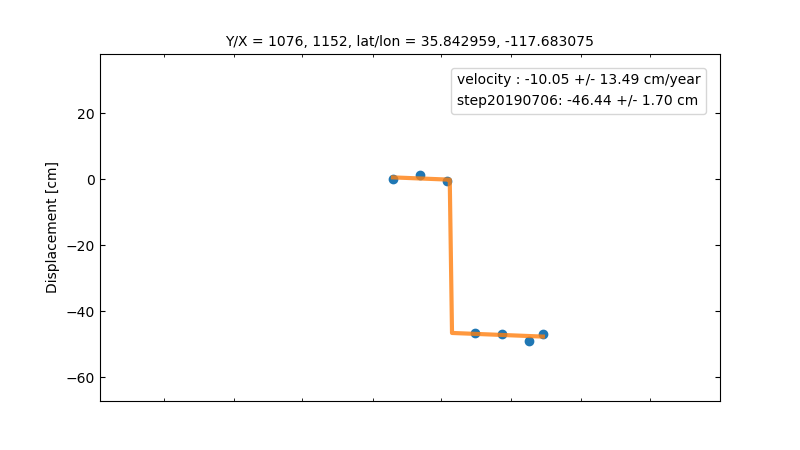

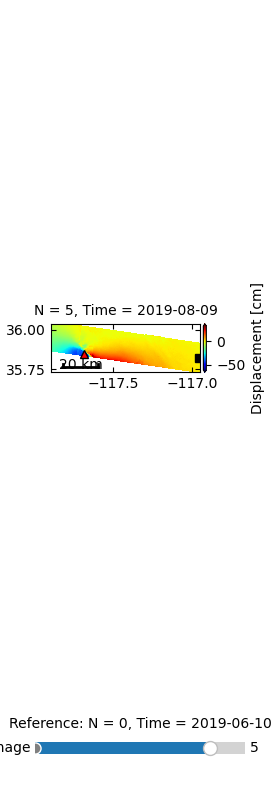

In [13]:
%matplotlib widget
from mintpy.cli import tsview
import os

ts_file = os.path.expanduser('./timeseries.h5')
cmd = f'{ts_file} --lalo 35.843 -117.683 --zero-first --ref-date 20190610 --step-date 20190706 --mask no'
tsview.main(cmd.split())